---
tags: [algorithm, finance, simulation]
---

# 量子コンピュータによるリスク分析

Value at Risk (VaR) や Conditional Value at Risk (CVaR) の計算は、金融リスクを定量化する上でとても重要です。
この計算には古典モンテカルロシミュレーション手法が用いられてきましたが、計算量が膨大なものとなる問題がありました。
その計算量を緩和し、より高速な計算を可能にする技術として、量子コンピュータによる手法が考案されています。
そこで本記事では、VaR および CVaR を量子コンピュータ乗で効率的に計算するアルゴリズムを提案した [Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6) を題材に、Qamomileによる実装の一例をまとめました。

In [1]:
# Install the latest Qamomile through pip! 
# !pip install qamomile

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import qamomile.circuit as qmc
from qamomile.circuit.algorithm.state_preparation import amplitude_encoding
from qamomile.circuit.stdlib.qft import iqft
from qamomile.qiskit import QiskitTranspiler
from scipy.stats import norm

## 背景

### 問題: VaR と CVaR の計算

リスク管理は、金融システムにおいて中心的な役割を担っています。
中でも VaR は「ある期間の間にある確率以内に収まる最大損失額はいくらか」を表し、そして CVaR は「VaRを下回る資産価値の期待値はいくらか」を示す、非常に重要な指標となっています。  
古典モンテカルロシミュレーションは、VaR と CVaR を求める標準的な手法です。
しかしサンプル数 $M$ に対し、その誤差は $\mathcal{O}(M^{-1/2})$ でスケールすることが知られており、その減衰の遅さがボトルネックとなっています。
その性能を改善したものとして、分散減少法 (variance reduction) や 準モンテカルロ法 (Quasi-Monte Carlo: QMC) などがあります。
前者は漸近的なスケーリングを変えずに定数を削減しますが、問題に応じた構造設計が必要で、汎用性に欠けます。
また後者は漸近的な振る舞いを改善しますが、その有効性は低次元に限られており、現実問題への適用には適していません。  
量子振幅推定 (QAE) は未知のパラメータを推定するための量子アルゴリズムであり、$\mathcal{O}(M^{-1})$ で収束することが知られています。
これはモンテカルロのような古典手法に対し、2次的な量子高速化を実現します。
そこで [Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6) では、QAE を確率分布の分散・VaR・CVaR の計算へと拡張する手法を提案しました。
また浅い回路の場合についても議論することで、その NISQ 実装についても焦点を当てました。

### 先行研究

QAEによりモンテカルロ計算を高速化できることを示した重要な研究に、[Montanaro (2015)](https://royalsocietypublishing.org/rspa/article/471/2181/20150301/57575/Quantum-speedup-of-Monte-Carlo-methodsQuantum) があります。
この研究では一般的な設定において、QAE がモンテカルロ法を高速化できることを理論的に示しました。
さらに量子ウォークと組合せることで、多段マルコフ連鎖モンテカルロ法による分配関数計算の古典手法を高速化できることも示しました。
そして金融デリバティブのモンテカルロプライシングのための量子アルゴリズムを提案した先行研究として、[Rebentrost et al. (2018)](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.98.022321) があります。
この論文では QAE を用いることで、プライシング推定値を得るために必要なステップ数において、2次的な量子高速化を達成できるという理論・数値シミュレーションを示しました。
しかし [Rebentrost et al. (2018)](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.98.022321) では期待値の計算にとどまっており、QAE を直接当てはめやすい問題設定 (より具体的にはデリバティブの公正価値の計算) のみに着目した計算を行なっていました。
VaR や CVaR を計算する問題は基本的に非線形であり、QAE をそのまま当てはめることはできません。
そこで [Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6) は QAE を、VaR と CVaR の計算という、より実務に即した指標計算に拡張しました。

## アルゴリズム

### 確率分布の量子状態符号化

最初に、確率変数 $X$ の分布を量子状態として表現しましょう。
$n$ 量子ビットを用い、確率変数の値域を $\{0, 1, \dots, N-1\} \ (N=2^n)$ で離散化します。
確率変数 $X$ を次のような量子状態で表すような、演算子 $\mathcal{R}$ を準備します。

$$
\mathcal{R} \vert 0 \rangle_n 
= \vert \psi \rangle_n
= \sum_{i=0}^{N-1} \sqrt{p_i} \vert i \rangle_n \tag{1}
$$

ここで $p_i$ は $\vert i \rangle_n$ が測定される確率であり、$\sum_i p_i = 1$ です。

### 目標演算子 $F$

次に、$f(i) \in [0, 1]$ のような関数と、これがアンシラ量子ビットの状態の係数として現れることを実現するような演算子を $F$ としましょう。

$$
F \vert i \rangle_n \vert 0 \rangle 
= \vert i \rangle_n \left( \sqrt{1-f(i)} \vert 0 \rangle + \sqrt{f(i)} \vert 1 \rangle \right) \tag{2}
$$

このような演算子 $F$ を式(1)に作用させることで

$$
F \vert \psi \rangle_n \vert 0 \rangle 
= \sum_{i=0}^{N-1} \sqrt{1-f(i)} \sqrt{p_i} \vert i \rangle_n \vert 0 \rangle + \sum_{i=0}^{N-1} \sqrt{f(i)} \sqrt{p_i} \vert i \rangle_n \vert 1 \rangle \tag{3}
$$

を得ます。
この状態において、アンシラ量子ビットが $\vert 1 \rangle$ となる確率を測定すると

$$
P_1 
= \sum_{i=0}^{N-1} f(i) p_i \tag{4}
$$

のようになります。
式(4)は関数 $f(i)$ の期待値 $\mathbb{E}[f(X)]$ に対応しますが、関数 $f(X)$ の形により求められる統計量が変化します。
次表は、求めたい統計量と関数 $f(i)$ の対応を示したものです。

|統計量|$f(i)$|
|-|-|
|$\mathbb{E}[X]$|$i/(N-1)$|
|$\mathbb{E}[X^2]$|$i^2/(N-1)^2$|

[Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6) では QAE を用いることで、$\vert 1 \rangle$ の前の係数 $P_1$ を推定します。  
$f(i)$ を直接 $F$ として量子回路に実装するには、多くの補助量子ビットを必要とします。
そこで [Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6) では次のような近似を行いました。
次数 $k$ の多項式 $\zeta(x)$ を用い、次のような演算を行う演算子を考えましょう。

$$
\vert x \rangle_n \vert 0 \rangle \longrightarrow
\vert x \rangle_n (\cos \zeta(x) \vert 0 \rangle + \sin \zeta(x) \vert 1 \rangle) \tag{5}
$$

これは多制御Y回転であり、$\mathcal{O}(n^{k+1})$ ゲートと $\mathcal{O}(n)$のアンシラで実装が可能です。
この演算後に補助量子ビットが $\vert 1 \rangle$ となる確率は $\sin^2 \zeta(x)$ となります。  
$\vert y \vert$ が小さいとき $\sin^2(y + \pi/4) \approx y + 1/2$ が成り立つことを利用し、$y = f(i) \in [0,1]$ とおくと

$$
c\!\left(y - \frac{1}{2}\right) + \frac{1}{2}
\approx \sin^2\!\left(c\,\zeta(y) + \frac{\pi}{4}\right)
\implies
\zeta(y) \approx \frac{1}{c}\!\left\{\arcsin\sqrt{c\!\left(y-\frac{1}{2}\right)
+\frac{1}{2}} - \frac{\pi}{4}\right\} \tag{6}
$$

のように変形できます。
これをさらに $y = 1/2$ の周りでテイラー展開 (次数 $2u+1$) して用いることにします。
$\zeta(y)$ は $y=1/2$ に対して奇関数であるため、偶数次の項がゼロとなり効率的に実装できます。
この近似の下で QAE を実行したときの全体誤差は

$$
\varepsilon = \mathcal{O}\!\left(M^{-\frac{2u+2}{2u+3}}\right) \tag{7}
$$

のように与えられます。
$u=0$（最小回路深さ）でも $\mathcal{O}(M^{-2/3})$ となり、古典モンテカルロ $\mathcal{O}(M^{-1/2})$ を凌駕する収束性を持ちます。
$u$ を増やすことで、最適な $\mathcal{O}(M^{-1})$ に漸近することがわかります。

### VaR と CVaR の計算

ここまでの計算を、VaR と CVaR に拡張しましょう。
与えられた信頼度 $\alpha \in [0, 1]$ に対し、$\mathrm{VaR}_\alpha (X)$ は $P[X \leq x] \geq 1-\alpha$ を満たす最小の $x \in \{0, 1, \dots, N-1\}$、すなわち損失分布の $1-\alpha$ 分位点です。
これを計算するには、$f_\ell (i) = \mathbf{1}(i \leq \ell)$ が考えられます。
ここで $\mathbf{1}(i \leq \ell)$ は、$i \leq \ell$ ならば1、そうでないなら0を返す二値関数で、指示関数と呼ばれます。
実際に、この $f_\ell (i)$ に対応する $F_\ell$ を $\vert \psi \rangle_n \vert 0 \rangle$ に作用させると

$$
F_\ell \vert \psi \rangle_n \vert 0 \rangle 
= \sum_{i=0}^{N-1} \sqrt{1-f_\ell(i)} \sqrt{p_i} \vert i \rangle_n \vert 0 \rangle + \sum_{i=0}^{N-1} \sqrt{f_\ell(i)} \sqrt{p_i} \vert i \rangle_n \vert 1 \rangle 
= \sum_{i=\ell+1}^{N-1} \sqrt{p_i} \vert i \rangle_n \vert 0 \rangle + \sum_{i=0}^\ell \sqrt{p_i} \vert i \rangle_n \vert 1 \rangle \tag{8}
$$

のようになり、アンシラ量子ビットにおける $\vert 1 \rangle$ の測定確率が $\sum_{i=0}^\ell p_i = P[X \leq \ell]$ のようになります。
先ほど説明したように、QAEを用いて $a_\ell = \mathbf{E}[f_\ell (X)] = P[X \leq \ell]$ を推定し、これを求めます。  
$\ell$ に関しては、二分探索を行えば良いでしょう。
二分探索を行うことで、$P[X \leq \ell_\alpha] \geq 1-\alpha$ を満たす最小の信頼度 $\ell_\alpha$ を、最大 $\mathcal{O}(\log 2^n) = \mathcal{O}(n)$ ステップで見つけることができます。  
続いて、CVaR の計算方法を見てみましょう。
VaR の計算から、 $\ell_\alpha = \mathrm{VaR}_\alpha (X)$ がすでに求まっているとします。
これを用いると、CVaR は次のように書くことができます。

$$
\mathrm{CVaR}_\alpha (X) 
= \mathbb{E} [X \vert X \leq \ell_\alpha] 
= \frac{\mathbb{E}[X \cdot \mathbf{1} [X \leq \ell_\alpha]]}{P[X \leq \ell_\alpha]} \tag{9}
$$

この式の分母の部分は VaR の計算に付随して得ることができます。
次に、分子について整理すると

$$
\mathbb{E} [X \cdot \mathbf{1} [X \leq \ell_\alpha]] 
= \sum_{i=0}^{N-1} i \mathbf{1} [i \leq \ell_\alpha] p_i 
= \sum_{i=0}^{\ell_\alpha} i p_i \tag{10}
$$

のようになります。
先ほど述べたように、関数 $f$ の期待値 $\mathbb{E} [f(X)]$ は QAE を用いて推定することができます。
しかし、QAE で推定できるのは $[0, 1]$ の範囲にある量 (すなわち確率) のみです。
式(10)は一般に $[0, 1]$ を超えるため、$0 \leq i \leq \ell_\alpha$ を $\ell_\alpha$ で割ることにしましょう。

$$
\mathbb{E} \left[ \frac{X}{\ell_\alpha} \cdot \mathbf{1} [X \leq \ell_\alpha] \right] 
= \sum_{i=0}^{\ell_\alpha} \frac{i}{\ell_\alpha} p_i \in [0, 1] \tag{11}
$$

式(4)と式(11)を見比べると、関数 $f(i)$ は

$$
f(i) 
= \frac{i}{\ell_\alpha} \mathbf{1} [i \leq \ell_\alpha] \tag{12}
$$

のようになります。
QAE でこの $\mathbb{E} [f(X)]$ を推定し、その後で $\ell_\alpha$ をかけることで、CVaRを求めることができます。

## Qamomileによる実装

それでは、[Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6) の実装を見ていきましょう。

### 古典コンピュータによる処理

まず、量子回路に渡す全てのパラメータを、古典コンピュータ上で事前計算する関数を定義します。
簡単のため、ここで量子回路に渡す分布は正規分布とします。
`make_normal_amplitudes` では正規分布を $N=2^n$ の点で離散化し、振幅符号化に必要な $\sqrt{p_i}$ を準備します。
`make_objective_angles_comparator` は、VaR 計算で必要となる $f(i) = \mathbf{1} [i \leq \ell] $ を準備します。
ただし、量子回路上では補助量子ビットへの回転角 $\theta_i$ を通してこれを実現するため、$\sin^2 (\theta_i / 2) = 1$ となる角度 $\theta_i = \pi$ と $\theta_i = 0$ をリストに格納しています。
`make_objective_angles_cvar` では、続く CVaR 計算で必要な $f(i) = \frac{i}{\ell_\alpha} \mathbf{1} [i \leq \ell_\alpha]$ の計算を行っています。
補助量子ビットが $\vert 1 \rangle$ になる確率を $f(i)$ に一致させるため

$$
f(i) 
= \sin^2 \frac{\theta_i}{2} \ \Longrightarrow \ 
\theta_i 
= 2 \mathrm{arcsin} \sqrt{\frac{i}{\ell_\alpha}} \tag{10}
$$

としています。

In [3]:
# ===================================================
# Step 0: 古典的な前処理
# ===================================================

def make_normal_amplitudes(n: int, mu: float = 0.0, sigma: float = 1.0) -> np.ndarray:
    N = 2 ** n
    x = np.linspace(mu - 3*sigma, mu + 3*sigma, N)
    probs = norm.pdf(x, mu, sigma)
    probs /= probs.sum()
    return np.sqrt(probs)

def make_objective_angles_comparator(n: int, l: int) -> list[float]:
    return [float(np.pi) if i <= l else 0.0 for i in range(2**n)]

def make_objective_angles_cvar(
    n: int, l_alpha: int, mu: float, sigma: float,
) -> list[float]:
    N = 2 ** n
    x_vals = np.linspace(mu - 3*sigma, mu + 3*sigma, N)
    x_min, x_max = x_vals[0], x_vals[-1]
    angles = []
    for i in range(N):
        if i <= l_alpha:
            fi = (x_vals[i] - x_min) / (x_max - x_min)
            fi = min(max(fi, 0.0), 1.0)
            angles.append(float(2 * np.arcsin(np.sqrt(fi))))
        else:
            angles.append(0.0)
    return angles

### カーネルの合成

次に、Qamomileを用いて量子演算を実装しましょう。
`_identity` は、のちに必要となる恒等演算を行うだけの関数です。
`merge_kernels` 関数は、2つのカーネル `left` と `right` を受け取り、それらを合成します。
`build_objective_kernel` では、$2^n$ 個のカーネルリスト `op_list` を、`merge_kernels` を繰り返し適用することで1つのカーネルに統合します。

In [4]:
# ===================================================
# Step 1: identity カーネル
# ===================================================

@qmc.qkernel
def _identity(
    q: qmc.Vector[qmc.Qubit], anc: qmc.Qubit,
) -> tuple[qmc.Vector[qmc.Qubit], qmc.Qubit]:
    return q, anc

# ===================================================
# Step 2: カーネルの合成ユーティリティ
# ===================================================

def merge_kernels(left, right):
    @qmc.qkernel
    def merged(
        q: qmc.Vector[qmc.Qubit], anc: qmc.Qubit,
    ) -> tuple[qmc.Vector[qmc.Qubit], qmc.Qubit]:
        q, anc = left(q, anc)
        q, anc = right(q, anc)
        return q, anc
    return merged

def build_objective_kernel(op_list: list):
    ops = list(op_list)
    while len(ops) > 1:
        next_ops = []
        for i in range(0, len(ops), 2):
            if i + 1 < len(ops):
                next_ops.append(merge_kernels(ops[i], ops[i + 1]))
            else:
                next_ops.append(ops[i])
        ops = next_ops
    return ops[0]

### 目標演算子 $F$ の実装

ここでは、式(2)の演算子 $F$ を実装します。
多制御 $R_y$ ゲート演算のためのカーネルを構築しますが、もし対応する角度が $\vert \theta \vert < \epsilon$ の場合には、回転を行わずに恒等演算を施すようにしています。
普通の多制御 $R_y$ 回転は、制御量子ビットが全て $\vert 1 \rangle$ のときのみ、ターゲット量子ビットを回転させます。
しかし今回必要なのは、例えば$\vert i=5 \rangle = \vert 101 \rangle$ に対応した角度 $\theta_5$ の回転です。
よって全ての制御量子ビットを $\vert 11 \cdots 1 \rangle$ に揃えるための $X$ フリップを行い、そこに対応する多制御 $R_y$ を施したのちに、再び $X$ フリップを行うことで制御量子ビット状態を元に戻す、という操作を実装しています。

In [5]:
eps = 1e-12

# ===================================================
# Step 3: 1基底分のカーネルを生成
# ===================================================

def make_x_kernel(b: int):
    @qmc.qkernel
    def x_op(
        q: qmc.Vector[qmc.Qubit], anc: qmc.Qubit,
    ) -> tuple[qmc.Vector[qmc.Qubit], qmc.Qubit]:
        q[b] = qmc.x(q[b])
        return q, anc
    return x_op

def make_single_op_kernel(n: int, bits_to_flip: list[int], angle: float):
    mcry = qmc.control(qmc.ry, num_controls=n)
    a = float(angle)
    if len(bits_to_flip) == 0:
        flip_kernel = _identity
    else:
        x_kernels = [make_x_kernel(b) for b in bits_to_flip]
        flip_kernel = x_kernels[0]
        for xk in x_kernels[1:]:
            flip_kernel = merge_kernels(flip_kernel, xk)

    @qmc.qkernel
    def mcry_kernel(
        q: qmc.Vector[qmc.Qubit], anc: qmc.Qubit,
    ) -> tuple[qmc.Vector[qmc.Qubit], qmc.Qubit]:
        q, anc = mcry(q, anc, angle=a)
        return q, anc

    return merge_kernels(merge_kernels(flip_kernel, mcry_kernel), flip_kernel)

def make_all_op_kernels(n: int, obj_angles: list[float]) -> list:
    N = 2 ** n
    kernels = []
    for i in range(N):
        angle = obj_angles[i]
        active = (angle > eps) or (angle < -eps)
        if active:
            bits_to_flip = [bit for bit in range(n) if not (i >> bit) & 1]
            kernels.append(make_single_op_kernel(n, bits_to_flip, angle))
        else:
            kernels.append(_identity)
    return kernels

### 量子振幅推定の実装

Groverの反射演算子 $\mathcal{Q}$ を量子位相推定 (QPE) にかけることで、振幅を推定するカーネルを実装しましょう。
この振幅推定により、$\mathbb{E}[f(X)]$ を推定したことになります。

In [6]:
# ===================================================
# Step 4: Fully QAE
# ===================================================

def make_a_kernel(n: int, amplitudes: np.ndarray, obj_angles: list[float]):
    """A = F · R カーネル"""
    op_list = make_all_op_kernels(n, obj_angles)
    objective_kernel = build_objective_kernel(op_list)

    @qmc.qkernel
    def a_kernel(
        q: qmc.Vector[qmc.Qubit], anc: qmc.Qubit,
    ) -> tuple[qmc.Vector[qmc.Qubit], qmc.Qubit]:
        q = amplitude_encoding(q, amplitudes)
        q, anc = objective_kernel(q, anc)
        return q, anc

    return a_kernel

def make_grover_q_kernel(n: int, a_ker, a_dag):
    """
    Grover 反射演算子 Q = A · S₀ · A† · Sχ

    Sχ に X→Z→X を使用。
    Z のみでは Q の固有値が -e^{±2iθ} になり QPE の位相が
    π ± 2θ にシフトするため、X→Z→X で符号を打ち消す。
    """
    @qmc.qkernel
    def s_chi(
        q: qmc.Vector[qmc.Qubit], anc: qmc.Qubit,
    ) -> tuple[qmc.Vector[qmc.Qubit], qmc.Qubit]:
        anc = qmc.x(anc)
        anc = qmc.z(anc)
        anc = qmc.x(anc)
        return q, anc

    mcz_n = qmc.control(qmc.z, num_controls=n)

    @qmc.qkernel
    def x_anc_kernel(
        q: qmc.Vector[qmc.Qubit], anc: qmc.Qubit,
    ) -> tuple[qmc.Vector[qmc.Qubit], qmc.Qubit]:
        anc = qmc.x(anc)
        return q, anc

    x_q_kernels = [make_x_kernel(b) for b in range(n)]
    x_all_q = x_q_kernels[0]
    for xk in x_q_kernels[1:]:
        x_all_q = merge_kernels(x_all_q, xk)
    x_all = merge_kernels(x_all_q, x_anc_kernel)

    @qmc.qkernel
    def mcz_kernel(
        q: qmc.Vector[qmc.Qubit], anc: qmc.Qubit,
    ) -> tuple[qmc.Vector[qmc.Qubit], qmc.Qubit]:
        q, anc = mcz_n(q, anc)
        return q, anc

    s_0 = merge_kernels(merge_kernels(x_all, mcz_kernel), x_all)

    return merge_kernels(
        merge_kernels(merge_kernels(s_chi, a_dag), s_0),
        a_ker,
    )

def make_q_power_kernel(q_kernel, power: int):
    if power == 1:
        return q_kernel
    result = q_kernel
    for _ in range(power - 1):
        result = merge_kernels(result, q_kernel)
    return result

def make_qae_kernel(
    n: int, m: int,
    amplitudes: np.ndarray,
    obj_angles: list[float],
):
    """
    QAE カーネル

    Step 2 の build_objective_kernel と同じ二分木合成を
    QPE ステップにも適用することで if/elif を排除。

    各 QPE ステップ（H + ctrl-Q^{2^k}）を make_qpe_step で
    個別カーネルとして生成し、build_qpe_kernel で二分木合成する。
    """
    a_ker = make_a_kernel(n, amplitudes, obj_angles)
    a_dag = qmc.inverse(a_ker)
    q_ker = make_grover_q_kernel(n, a_ker, a_dag)

    # ---------------------------------------------------
    # QPE ステップ用の合成ユーティリティ
    # ---------------------------------------------------

    def merge_qpe_steps(left, right):
        """
        2つの QPE ステップカーネルを順に適用するカーネルを返す。
        引数形式：(sv, q, anc) → (sv, q, anc)
        """
        @qmc.qkernel
        def merged_step(
            sv:  qmc.Vector[qmc.Qubit],
            q:   qmc.Vector[qmc.Qubit],
            anc: qmc.Qubit,
        ) -> tuple[qmc.Vector[qmc.Qubit], qmc.Vector[qmc.Qubit], qmc.Qubit]:
            sv, q, anc = left(sv, q, anc)
            sv, q, anc = right(sv, q, anc)
            return sv, q, anc
        return merged_step

    def build_qpe_kernel(step_list: list):
        """
        step_list（長さ m）の QPE ステップカーネルを
        二分木合成で1つのカーネルに統合する。
        build_objective_kernel と全く同じ構造。
        """
        steps = list(step_list)
        while len(steps) > 1:
            next_steps = []
            for i in range(0, len(steps), 2):
                if i + 1 < len(steps):
                    next_steps.append(merge_qpe_steps(steps[i], steps[i + 1]))
                else:
                    next_steps.append(steps[i])
            steps = next_steps
        return steps[0]

    # ---------------------------------------------------
    # k 番目の QPE ステップカーネルを生成
    # H(sv[k]) → ctrl-Q^{2^k}(sv[k], q, anc)
    # ---------------------------------------------------

    def make_qpe_step(k: int):
        cqk = qmc.control(make_q_power_kernel(q_ker, 2**k))
        sk  = k

        @qmc.qkernel
        def qpe_step(
            sv:  qmc.Vector[qmc.Qubit],
            q:   qmc.Vector[qmc.Qubit],
            anc: qmc.Qubit,
        ) -> tuple[qmc.Vector[qmc.Qubit], qmc.Vector[qmc.Qubit], qmc.Qubit]:
            sv[sk] = qmc.h(sv[sk])
            sv[sk], q, anc = cqk(sv[sk], q, anc)
            return sv, q, anc

        return qpe_step

    # m 個の QPE ステップを生成して二分木合成
    step_kernels = [make_qpe_step(k) for k in range(m)]
    qpe_kernel   = build_qpe_kernel(step_kernels)

    # ---------------------------------------------------
    # メインの QAE カーネル
    #
    # 構造：
    #   1. A でメインレジスタを初期化
    #   2. QPE（m ステップを qpe_kernel として一括適用）
    #   3. IQFT を sv に適用
    #   4. sv を測定
    # ---------------------------------------------------

    @qmc.qkernel
    def qae_kernel() -> qmc.Vector[qmc.Bit]:
        q   = qmc.qubit_array(n, name="q")
        anc = qmc.qubit(name="anc")
        sv  = qmc.qubit_array(m, name="sv")

        q, anc = a_ker(q, anc)              # A でメインレジスタを初期化
        sv, q, anc = qpe_kernel(sv, q, anc)  # QPE（全 m ステップ）
        sv = iqft(sv)                        # 逆 QFT
        return qmc.measure(sv)               # sv を測定

    return qae_kernel
    
def estimate_amplitude_qae(
    n: int, m: int,
    amplitudes: np.ndarray,
    obj_angles: list[float],
    shots: int = 4096,
) -> float:
    M = 2 ** m
    transpiler = QiskitTranspiler()
    kernel = make_qae_kernel(n, m, amplitudes, obj_angles)
    exe = transpiler.transpile(kernel)
    result = exe.sample(transpiler.executor(), shots=shots).result()

    counts: dict[int, int] = {}
    for outcome, count in result.results:
        # qmc.Vector[qmc.Bit] の測定結果はタプルまたはネストしたタプルで返る
        if isinstance(outcome, (int, np.integer)):
            y = int(outcome)
        elif isinstance(outcome, tuple):
            flat = []
            for b in outcome:
                if isinstance(b, tuple):
                    flat.extend(int(x) for x in b)
                else:
                    flat.append(int(b))
            y = sum(bit * (2**k) for k, bit in enumerate(flat))
        else:
            y = int(outcome)
        counts[y] = counts.get(y, 0) + count

    y_star = max(counts, key=counts.get)
    if y_star > M // 2:
        y_star = M - y_star

    return float(np.sin(y_star * np.pi / M) ** 2)

### VaRとCVaRの計算

QAEによる $P[X \leq \ell]$ の推定と、二部探索を組合せることで、$\mathrm{VaR}_\alpha$ を求めましょう。
各ステップで中間点 $\ell_\mathrm{mid}$ の累積確率を QAE で推定し、$1-\alpha$ との大小比較から探索範囲を縮小していきます。
このようにして VaR の計算を行い、さらに VaR 計算で得た数値から CVaR の計算も行います。
CVaR の計算には、追加の QAE を1回実行します。

In [7]:
# ===================================================
# Step 5: VaR の計算
# ===================================================

def compute_var(
    alpha: float, n: int, m: int,
    amplitudes: np.ndarray,
    mu: float, sigma: float,
    shots: int = 4096,
) -> tuple[int, float, float]:
    """
    完全 QAE による二分探索で VaR_α を計算する。

    n 回の二分探索 × 各ステップで QAE を1回実行。
    合計 n+1 回の QAE で VaR と P[X ≤ VaR] を求める。
    """
    N = 2 ** n
    x_vals = np.linspace(mu - 3*sigma, mu + 3*sigma, N)
    l_low, l_high = 0, N - 1

    print(f"  VaR 計算開始（n={n}, m={m}, N={N}, M={2**m}）")
    for step in range(n):
        l_mid = (l_low + l_high) // 2
        obj_angles = make_objective_angles_comparator(n, l_mid)
        prob = estimate_amplitude_qae(n, m, amplitudes, obj_angles, shots=shots)
        print(f"    Step {step+1}/{n}: l_mid={l_mid} "
              f"(x={x_vals[l_mid]:.3f}), P[X≤l_mid]≈{prob:.4f}")
        if prob >= 1 - alpha:
            l_high = l_mid
        else:
            l_low = l_mid

    var_alpha_index = l_high
    var_alpha_x = x_vals[var_alpha_index]
    prob_var = estimate_amplitude_qae(
        n, m, amplitudes,
        make_objective_angles_comparator(n, var_alpha_index),
        shots=shots,
    )
    print(f"  → VaR_{1-alpha:.0%} = index {var_alpha_index} "
          f"(x = {var_alpha_x:.4f}), P[X≤VaR]≈{prob_var:.4f}")
    return var_alpha_index, var_alpha_x, prob_var

# ===================================================
# Step 6: CVaR の計算
# ===================================================

def compute_cvar(
    alpha: float,
    var_alpha_index: int, var_alpha_x: float, prob_var: float,
    n: int, m: int,
    amplitudes: np.ndarray,
    mu: float, sigma: float,
    shots: int = 4096,
) -> float:
    """
    完全 QAE による CVaR_α の計算。

    VaR の結果を使って追加 1 回の QAE を実行し
    CVaR = (E[f(X)]·(x_max-x_min) + x_min·P[X≤l_α]) / P[X≤l_α]
    として復元する。
    """
    N = 2 ** n
    x_vals = np.linspace(mu - 3*sigma, mu + 3*sigma, N)
    x_min, x_max = x_vals[0], x_vals[-1]
    obj_angles = make_objective_angles_cvar(n, var_alpha_index, mu, sigma)
    ef = estimate_amplitude_qae(n, m, amplitudes, obj_angles, shots=shots)
    return (ef * (x_max - x_min) + x_min * prob_var) / prob_var \
           if prob_var > 0 else 0.0

### 可視化とメイン実行

結果をわかりやすく見るために、読み込んだ分布と VaR・CVaR を描画するグラフのための関数を実装しましょう。

In [8]:
# ===================================================
# Step 7: 可視化（m を変化させた場合の精度比較）
# ===================================================

def plot_results_vs_m(
    results_by_m: dict,
    n: int,
    alpha: float,
    mu: float,
    sigma: float,
):
    """
    m を変化させたときの VaR・CVaR 推定精度を可視化する。

    上段：各 m の損失分布と VaR・CVaR の位置
    下段左：m ごとの VaR 推定値と理論値の比較
    下段右：m ごとの CVaR 推定値と古典真値・理論値の比較
    """
    m_list = sorted(results_by_m.keys())
    N = 2 ** n
    x_vals = np.linspace(mu - 3*sigma, mu + 3*sigma, N)
    probs = norm.pdf(x_vals, mu, sigma)
    probs /= probs.sum()

    theory_var  = norm.ppf(1 - alpha, mu, sigma)
    theory_cvar = mu - sigma * norm.pdf(norm.ppf(alpha)) / alpha

    # 古典真値（離散）：VaR インデックスごとに計算
    def classical_cvar(var_idx):
        prob_var_true = sum(probs[i] for i in range(var_idx + 1))
        if prob_var_true == 0:
            return 0.0
        return sum(x_vals[i] * probs[i] for i in range(var_idx + 1)) / prob_var_true

    n_cols = len(m_list)
    fig = plt.figure(figsize=(4 * n_cols, 10))
    gs = plt.GridSpec(
        2, n_cols,
        hspace=0.5, wspace=0.35,
        height_ratios=[2, 1],
    )

    var_estimates  = []
    cvar_estimates = []
    cvar_classical = []

    # ===== 上段：各 m の分布と VaR・CVaR =====
    for col, m in enumerate(m_list):
        ax = fig.add_subplot(gs[0, col])
        res = results_by_m[m]

        var_idx  = res["var_alpha_index"]
        var_x    = res["var_alpha_x"]
        cvar_val = res["cvar_alpha"]
        cvar_cl  = classical_cvar(var_idx)

        var_estimates.append(var_x)
        cvar_estimates.append(cvar_val)
        cvar_classical.append(cvar_cl)

        bar_width = (x_vals[1] - x_vals[0]) * 0.85
        ax.bar(
            x_vals[:var_idx + 1], probs[:var_idx + 1],
            width=bar_width, color="#D85A30", alpha=0.6,
            label="CVaR region",
        )
        ax.bar(
            x_vals[var_idx + 1:], probs[var_idx + 1:],
            width=bar_width, color="#1f77b4", alpha=0.6,
        )
        ax.axvline(x=var_x, color="#D85A30", linestyle="--",
                   linewidth=1.8, label=f"VaR = {var_x:.2f}")
        ax.axvline(x=cvar_val, color="#7F77DD", linestyle=":",
                   linewidth=1.8, label=f"CVaR = {cvar_val:.2f}")
        ax.axvline(x=theory_var, color="gray", linestyle="-.",
                   linewidth=1.0, alpha=0.7,
                   label=f"Theoretical VaR = {theory_var:.2f}")

        ax.set_title(f"$m={m}$ ($M={2**m}$)", fontsize=11)
        ax.set_xlabel("Price $X$", fontsize=9)
        ax.set_ylabel("Probability", fontsize=9)
        ax.legend(fontsize=6, loc="upper left")
        ax.set_xlim(x_vals[0] - 0.2, x_vals[-1] + 0.2)

    plt.suptitle(
        f"Quantum Risk Analysis — Woerner & Egger (2019)\n"
        f"Fully QAE: fixed $n={n}$ ($N={N}$), varied $m$ \n"
        f"($\\alpha={alpha}$, $\\mu={mu}$, $\\sigma={sigma}$)",
        fontsize=12, y=1.01,
    )
    plt.show()

ここまで実装したものを実行するメイン部分を書いて、完成です。

Quantum Risk Analysis — Fully QAE (based on QPE)
n=4 固定 (N=16), m を変化: [1, 3, 5]
α=0.05, μ=0.0, σ=1.0

理論値: VaR=1.6449, CVaR=-2.0627


m=1 (M=2)
  VaR 計算開始（n=4, m=1, N=16, M=2）
    Step 1/4: l_mid=7 (x=-0.200), P[X≤l_mid]≈0.0000
    Step 2/4: l_mid=11 (x=1.400), P[X≤l_mid]≈1.0000
    Step 3/4: l_mid=9 (x=0.600), P[X≤l_mid]≈1.0000
    Step 4/4: l_mid=8 (x=0.200), P[X≤l_mid]≈1.0000
  → VaR_95% = index 8 (x = 0.2000), P[X≤VaR]≈1.0000

--- 結果 ---
VaR_95%  = 0.2000  （理論値 1.6449）
CVaR_95% = -3.0000  （理論値 -2.0627）

m=3 (M=8)
  VaR 計算開始（n=4, m=3, N=16, M=8）
    Step 1/4: l_mid=7 (x=-0.200), P[X≤l_mid]≈0.5000
    Step 2/4: l_mid=11 (x=1.400), P[X≤l_mid]≈0.8536
    Step 3/4: l_mid=13 (x=2.200), P[X≤l_mid]≈1.0000
    Step 4/4: l_mid=12 (x=1.800), P[X≤l_mid]≈1.0000
  → VaR_95% = index 12 (x = 1.8000), P[X≤VaR]≈1.0000

--- 結果 ---
VaR_95%  = 1.8000  （理論値 1.6449）
CVaR_95% = -0.0000  （理論値 -2.0627）

m=5 (M=32)
  VaR 計算開始（n=4, m=5, N=16, M=32）
    Step 1/4: l_mid=7 (x=-0.200), P[X≤l_mid]≈0.5000
    Step

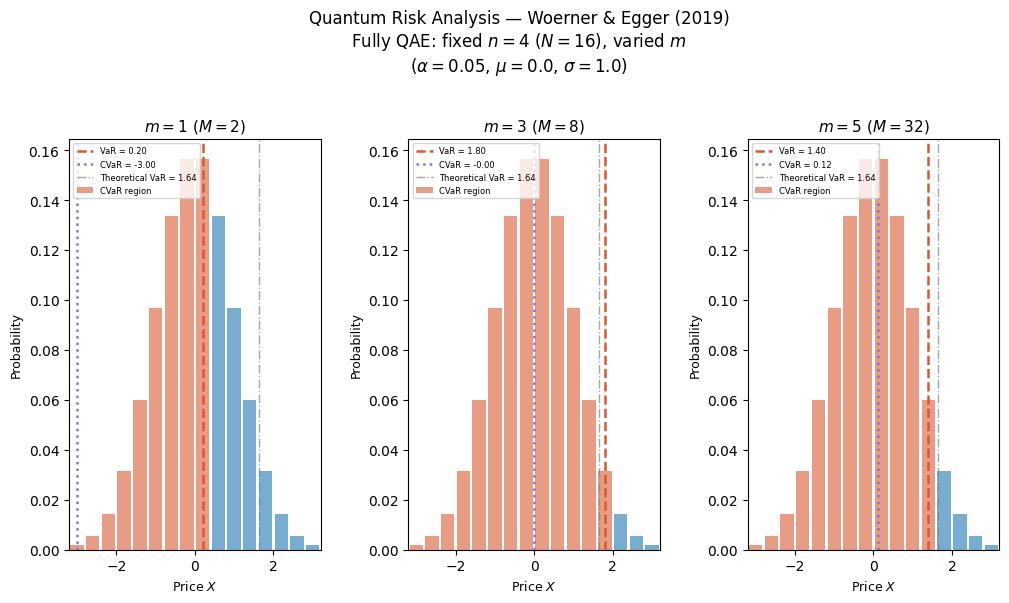

In [9]:
# ===================================================
# メイン実行
# ===================================================

alpha  = 0.05
shots  = 4096
mu     = 0.0
sigma  = 1.0
n      = 4        # 量子ビット数を固定
m_list = [1, 3, 5]  # m を変化させる

print("=" * 55)
print(f"Quantum Risk Analysis — Fully QAE (based on QPE)")
print(f"n={n} 固定 (N={2**n}), m を変化: {m_list}")
print(f"α={alpha}, μ={mu}, σ={sigma}")
print("=" * 55)

theory_var  = norm.ppf(1 - alpha, mu, sigma)
theory_cvar = mu - sigma * norm.pdf(norm.ppf(alpha)) / alpha
print(f"\n理論値: VaR={theory_var:.4f}, CVaR={theory_cvar:.4f}\n")

amplitudes = make_normal_amplitudes(n, mu=mu, sigma=sigma)
results_by_m = {}

for m in m_list:
    print(f"\n{'='*45}")
    print(f"m={m} (M={2**m})")
    print(f"{'='*45}")

    var_idx, var_x, prob_var = compute_var(
        alpha, n, m, amplitudes, mu=mu, sigma=sigma, shots=shots
    )
    cvar = compute_cvar(
        alpha, var_idx, var_x, prob_var,
        n, m, amplitudes, mu=mu, sigma=sigma, shots=shots
    )

    print(f"\n--- 結果 ---")
    print(f"VaR_{1-alpha:.0%}  = {var_x:.4f}  （理論値 {theory_var:.4f}）")
    print(f"CVaR_{1-alpha:.0%} = {cvar:.4f}  （理論値 {theory_cvar:.4f}）")

    results_by_m[m] = {
        "var_alpha_index": var_idx,
        "var_alpha_x":     var_x,
        "prob_var":        prob_var,
        "cvar_alpha":      cvar,
    }

plot_results_vs_m(
    results_by_m,
    n=n,
    alpha=alpha,
    mu=mu,
    sigma=sigma,
)

入力として用いた正規分布と、計算された VaR と CVaR を縦線で表示しています。
オレンジ色の棒グラフは VaR 以下の領域、青色部分は VaR を超える領域を示しています。
$m$ は QAE のサブルーチンとして用いられている QPE のサンプリング量子ビット数であり、QPE が推定可能な振幅の候補の数 ($M = 2^m$ 個) を決めるものです。
$m$ を増やすことで、VaR と CVaR の計算精度が向上していることがわかります。
QAE の誤差は $\mathcal{O}(M^{-1})$ で収束しますが、この問題設定では $n$ の小ささによる離散化誤差も発生します。
より精度を高めたければ、$m, n$ の両方を増やすことが必要となります。